least squares weights:  [ 151.72264646   19.92730105 -262.5526422   509.19584695  336.09319329
 -849.30479304  480.22664735  120.69064852  236.72228404  716.61278802
   70.41001991]
sklearn weights:  151.7226464572191 [  19.92730105 -262.5526422   509.19584695  336.09319329 -849.30479304
  480.22664735  120.69064852  236.72228404  716.61278802   70.41001991]
least squares MSE:  2743.911237757679
sklearn MSE:  2743.911237757697


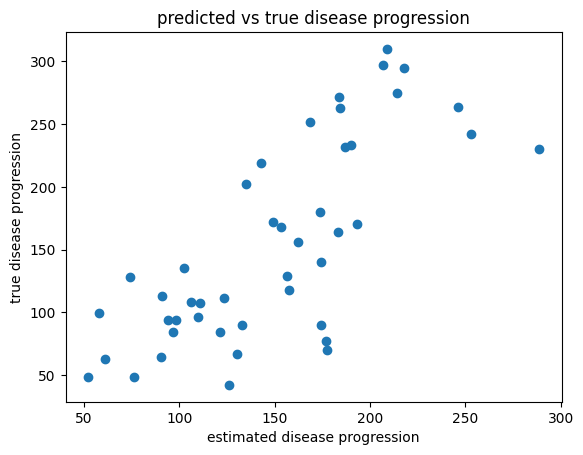

In [52]:
# This code compares training a linear model using least squares from scratch and using the .fit sklearn command. It turns out, they appear to be the same thing

import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ------------loading data--------------
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True) # load diabetes data set
diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(diabetes_X, diabetes_y, test_size=0.1, random_state=42) # split dataset into training and testing sets

# --------------sklearn model creation and training--------------
regr = linear_model.LinearRegression() # create a linear model to test
regr.fit(diabetes_X_train, diabetes_y_train) # fit sklearn's linear model

# -------------linear model from scratch----------------
num_features = np.size(diabetes_X_train, axis=1) # getting number of features so we know how many weights to use
constant_col = np.ones(np.size(diabetes_X_train, axis=0)) # creating column of 1's to use for training intercept
train_matrix = np.hstack((constant_col.reshape(-1,1), diabetes_X_train)) # appending intercept column to training data
weights = np.zeros(num_features + 1) # we add 1 so we can train a constant term that will be our intercept

# --------------training model-------------------
aTa_inv = np.linalg.inv(train_matrix.T @ train_matrix)
aTb = train_matrix.T @ diabetes_y_train
weights = aTa_inv @ aTb

# ----------------model comparison-------------
diabetes_y_pred = regr.predict(diabetes_X_test) # running predictions for sklearn model

constant_col = np.ones(np.size(diabetes_X_test, axis=0)) # adding an extra column which is multuplied by a constant to give +b term in Ax+b
test_matrix = np.hstack((constant_col.reshape(-1,1), diabetes_X_test)) # adding column to test data
least_squares_y_pred = weights @ test_matrix.T # running predictions for model from scratch

# -----------comparing weights and overall performance of model------------------
print('least squares weights: ', weights)
print('sklearn weights: ', regr.intercept_,regr.coef_)

print('least squares MSE: ', np.mean(np.square(least_squares_y_pred - diabetes_y_test)))
print('sklearn MSE: ', np.mean(np.square(diabetes_y_pred - diabetes_y_test)))

plt.xlabel('estimated disease progression')
plt.ylabel('true disease progression')
plt.title('predicted vs true disease progression')
plt.scatter(least_squares_y_pred, diabetes_y_test)
plt.show()